In [ ]:
import xarray as xr

ds = xr.open_dataset("../data/raw/nclimgrid_tmax.nc")

print(ds)
print(ds.data_vars)

var_name = list(ds.data_vars)[0]
print("Using variable:", var_name)

first_month = ds[var_name].isel(time=0)
first_month.plot()

In [ ]:
import xarray as xr

ds = xr.open_dataset("../data/raw/nclimgrid_tmax.nc")

var_name = list(ds.data_vars)[0]
print("Using variable:", var_name)

# Restrict to 2026 only
ds_2026 = ds.sel(time=slice("2026-01-01", "2026-12-31"))

# Grab and plot first available month in 2026
first_month_2026 = ds_2026[var_name].isel(time=0)
first_month_2026.plot()

# Rough bbox for Florida
# IMPORTANT: lat is descending in this dataset, so use slice(31, 24)
sub = ds_2026[var_name].sel(
    lat=slice(31, 24),
    lon=slice(-88, -80)
)

print("Sub sizes:", sub.sizes)
print("Lat range:", float(sub.lat.min()), float(sub.lat.max()))
print("Lon range:", float(sub.lon.min()), float(sub.lon.max()))
print(sub)

# Compare latest available 2026 month against 2026 mean so far
anomaly = sub.isel(time=-1) - sub.mean(dim="time")

anomaly.plot(cmap="RdBu_r")

In [1]:
# Cell 1: inspect the dataset
import xarray as xr
import matplotlib.pyplot as plt

ds = xr.open_dataset("../data/raw/nclimgrid_tmax.nc")
print(ds)

<xarray.Dataset> Size: 5GB
Dimensions:  (time: 1577, lat: 596, lon: 1385)
Coordinates:
  * time     (time) datetime64[ns] 13kB 1895-01-01 1895-02-01 ... 2026-05-01
  * lat      (lat) float32 2kB 49.35 49.31 49.27 49.23 ... 24.65 24.6 24.56
  * lon      (lon) float32 6kB -124.7 -124.6 -124.6 ... -67.1 -67.06 -67.02
Data variables:
    tmax     (time, lat, lon) float32 5GB ...
Attributes: (12/14)
    date_created:              2026-01-07 10:30:35.970148
    date_modified:             2026-01-07 10:30:35.970269
    Conventions:               CF-1.6, ACDD-1.3
    ncei_template_version:     NCEI_NetCDF_Grid_Template_v2.0
    title:                     nClimGrid
    naming_authority:          gov.noaa.ncei
    ...                        ...
    geospatial_lat_min:        24.562532
    geospatial_lat_max:        49.3542
    geospatial_lon_min:        -124.6875
    geospatial_lon_max:        -67.020836
    geospatial_lat_units:      degrees_north
    geospatial_lon_units:      degrees_east


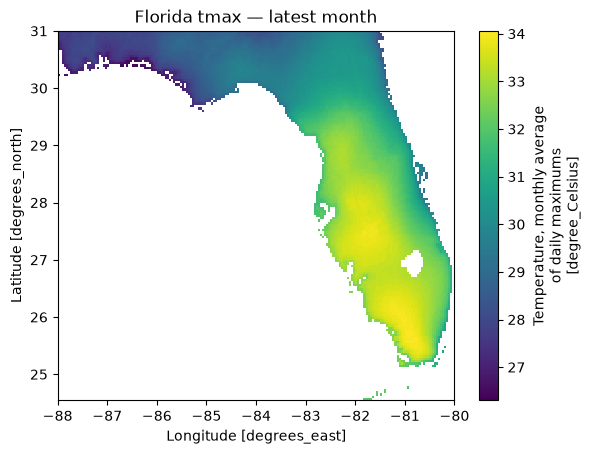

In [2]:
# Cell 2: raw plot — Florida, latest month
sub = ds["tmax"].sel(lat=slice(31, 24), lon=slice(-88, -80))
sub.isel(time=-1).plot()
plt.title("Florida tmax — latest month")
plt.show()

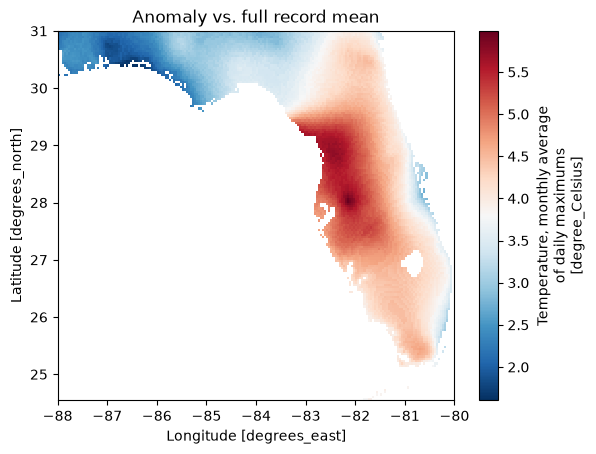

In [3]:
# Cell 3: anomaly against full record mean
anomaly = sub.isel(time=-1) - sub.mean(dim="time")
anomaly.plot(cmap="RdBu_r")
plt.title("Anomaly vs. full record mean")
plt.show()